<a href="https://colab.research.google.com/github/mariangelesalomar-sudo/eigenfaces-dma-grupo-1/blob/main/GRUPO_1__zBackPropagation_multiclase.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Algoritmo de BackPropagation multiclase

Este codigo se utilizará para entrenar la red neuronal de clasificacion de Nuestras Caras



### Código en Python del Algoritmo de BackPropagation

La clase del dataset debe ser categorica
Existe una clase en Python que resuelve el problema

In [4]:
# conexion al Google Drive
from google.colab import drive
drive.mount('/content/.drive')
!mkdir -p "/content/.drive/My Drive/DMA"
!mkdir -p "/content/buckets"
!ln -s "/content/.drive/My Drive/DMA" /content/buckets/b1

Mounted at /content/.drive


In [6]:
# instalo  itables solo si no esta instalado
!pip show itables >/dev/null || pip install itables

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 29.6 MB/s eta 0:00:00


In [7]:
import polars as pl
import numpy as np
import math
import matplotlib.pyplot as plt
%matplotlib inline
from IPython import display
import time
import os
import pickle
from functools import reduce
from itables import init_notebook_mode
init_notebook_mode(all_interactive=True)


In [8]:
# definicion de la clase de graficos
# ADAPTACION: guard para datos con mas de 2 dimensiones
# (nuestro caso: 80 componentes PCA/ISOMAP)
# En ese caso se imprime epoch y MSE por consola en vez de graficar
# las rectas de decision, que solo tienen sentido en 2D.

class perceptron_plot:
    """plotting first hidden layer class"""
    def __init__(self, X, Y, delay) -> None:
        self.X = X
        self.Y = Y
        self.delay = delay
        self.es_2d = (X.shape[1] == 2)

        if not self.es_2d:
            return  # no inicializar grafico si >2D

        x1_min = np.min(X[:,0])
        x2_min = np.min(X[:,1])
        x1_max = np.max(X[:,0])
        x2_max = np.max(X[:,1])
        self.x1_min = x1_min - 0.1*(x1_max - x1_min)
        self.x1_max = x1_max + 0.1*(x1_max - x1_min)
        self.x2_min = x2_min - 0.1*(x2_max - x2_min)
        self.x2_max = x2_max + 0.1*(x2_max - x2_min)
        self.fig = plt.figure(figsize = (10,8))
        self.ax = self.fig.subplots()
        self.ax.set_xlim(self.x1_min, self.x1_max, auto=False)
        self.ax.set_ylim(self.x2_min, self.x2_max, auto=False)

    def graficarVarias(self, W, x0, epoch, error) -> None:
        if not self.es_2d:
            # Con 80 componentes no tiene sentido graficar rectas de decision
            # Se imprime el progreso por consola
            display.clear_output(wait=True)
            print(f"epoch {epoch:>6d}  |  MSE {error:.6f}")
            return

        display.clear_output(wait=True)
        plt.cla()
        self.ax.set_xlim(self.x1_min, self.x1_max)
        self.ax.set_ylim(self.x2_min, self.x2_max)
        plt.title('epoch ' + str(epoch) + '  reg ' + "{0:.2E}".format(error))
        scatter = self.ax.scatter(self.X[:,0], self.X[:,1], c=self.Y, s=20)
        for i in range(len(x0)):
            vx2_min = -(W[i,0]*self.x1_min + x0[i])/W[i,1]
            vx2_max = -(W[i,0]*self.x1_max + x0[i])/W[i,1]
            self.ax.plot([self.x1_min, self.x1_max],
                         [vx2_min, vx2_max],
                         linewidth=2, color='red', alpha=0.5)
        display.display(plt.gcf())
        time.sleep(self.delay)

In [9]:
# definicion de las funciones de activacion
#  y sus derivadas
#  ahora agregando las versiones VECTORIZADAS

def func_eval(fname, x):
    match fname:
        case "purelin":
            y = x
        case "logsig":
            y = 1.0 / ( 1.0 + math.exp(-x) )
        case "tansig":
            y = 2.0 / ( 1.0 + math.exp(-2.0*x) ) - 1.0
    return y

# version vectorizada de func_eval
func_eval_vec = np.vectorize(func_eval)


def deriv_eval(fname, y):  #atencion que y es la entrada y=f( x )
    match fname:
        case "purelin":
            d = 1.0
        case "logsig":
            d = y*(1.0-y)
        case "tansig":
            d = 1.0 - y*y
    return d


# version vectorizada de deriv_eval
deriv_eval_vec = np.vectorize(deriv_eval)

### Clase  multiperceptron
entrenar, predecir

In [10]:
# definicion de la clase de multiperceptron
# FIXES aplicados respecto al original del profe:
#   1. entrenar(): carpeta → self.carpeta en el pickle (evita NameError)
#   2. predecir(): epoch y MSE tomados de self.red['work'] (evita NameError)
#   3. predecir(): se salta el grafico si los datos tienen mas de 2 dimensiones
#   4. predecir(): columna clase hardcodeada a "y" → usa el parametro clase

class multiperceptron(object):
    """Multiperceptron class"""

    # inicializacion de los pesos de todas las capas
    def _red_init(self, semilla) -> None:
        niveles = self.red['arq']['layers_qty']
        np.random.seed(semilla)
        for i in range(niveles):
           nivel = dict()
           nivel['id'] = i
           nivel['last'] = (i==(niveles-1))
           nivel['size'] = self.red["arq"]["layers_size"][i]
           nivel['func'] = self.red["arq"]["layers_func"][i]
           if( i==0 ):
              entrada_size = self.red['arq']['input_size']
           else:
              entrada_size = self.red['arq']['layers_size'][i-1]
           salida_size = nivel['size']
           nivel['W'] = np.random.uniform(-0.5, 0.5, [salida_size, entrada_size])
           nivel['w0'] = np.random.uniform(-0.5, 0.5, [salida_size, 1])
           nivel['W_m'] = np.zeros([salida_size, entrada_size])
           nivel['w0_m'] = np.zeros([salida_size, 1])
           self.red['layer'].append(nivel)

    # constructor generico
    def __init__(self) -> None:
        self.data = dict()
        self.red = dict()
        self.carpeta = ""

    # inicializacion full
    def inicializar(self, df, campos, clase, hidden_layers_sizes, layers_func,
                 semilla, carpeta) -> None:
        self.data['X'] = np.array( df.select(campos))
        X_mean = self.data['X'].mean(axis=0)
        X_sd = self.data['X'].std(axis=0)
        self.data['X'] = (self.data['X'] - X_mean)/X_sd
        label = df.select(clase)
        self.data['Ylabel'] = np.array(label).reshape(len(label))
        col_originales = df.columns
        self.data['Y'] = np.array( df.to_dummies(clase).drop(col_originales, strict=False) )
        col_dummies = sorted( list( set(df.to_dummies(clase).columns) - set(col_originales)))
        clases_originales = reduce(lambda acc, x: acc + [x[(len(clase)+1):]], col_dummies, [])
        tamanos = hidden_layers_sizes
        tamanos.append(self.data['Y'].shape[1])
        arquitectura = {
             'input_size' : self.data['X'].shape[1],
             'input_mean' : X_mean,
             'input_sd'   : X_sd,
             'output_values' : clases_originales,
             'layers_qty' : len(hidden_layers_sizes),
             'layers_size': tamanos,
             'layers_func': layers_func,
        }
        self.red['arq'] = arquitectura
        self.red['work'] = dict()
        self.red['work']['epoch'] = 0
        self.red['work']['MSE'] = float('inf')
        self.red['work']['train_error_rate'] = float('inf')
        self.red['layer'] = list()
        self._red_init(semilla)
        self.carpeta = carpeta
        os.makedirs(self.carpeta, exist_ok=True)
        with open(self.carpeta+"/data.pkl", 'wb') as f:
            pickle.dump(self.data, f)
        with open(self.carpeta+"/red.pkl", 'wb') as f:
            pickle.dump(self.red, f)

    # Algoritmo Backpropagation
    def entrenar(self, epoch_limit, MSE_umbral,
               learning_rate, lr_momento, save_frequency,
               retomar=True) -> None:
        if retomar:
            with open(self.carpeta+"/data.pkl", 'rb') as f:
              self.data = pickle.load(f)
            with open(self.carpeta+"/red.pkl", 'rb') as f:
              self.red = pickle.load(f)
        epoch = self.red['work']['epoch']
        MSE = self.red['work']['MSE']
        grafico = perceptron_plot(X=self.data['X'], Y=self.data['Ylabel'], delay=0.1)
        Xfilas = self.data['X'].shape[0]
        niveles = self.red["arq"]["layers_qty"]

        while ( MSE > MSE_umbral) and (epoch < epoch_limit):
          epoch += 1
          for fila in range(Xfilas):
             x = self.data['X'][fila:fila+1,:]
             clase = self.data['Y'][fila:fila+1,:]
             entrada = x.T
             vsalida = [0] * niveles
             for i in range(niveles):
               estimulos = self.red['layer'][i]['W'] @ entrada + self.red['layer'][i]['w0']
               vsalida[i] = func_eval_vec(self.red['layer'][i]['func'], estimulos)
               entrada = vsalida[i]
             verror = [0] * (niveles+1)
             verror[niveles] = clase.T - vsalida[niveles-1]
             i = niveles-1
             verror[i] = verror[i+1] * deriv_eval_vec(self.red['layer'][i]['func'], vsalida[i])
             for i in reversed(range(niveles-1)):
               verror[i] = deriv_eval_vec(self.red['layer'][i]['func'], vsalida[i]) * (self.red['layer'][i+1]['W'].T @ verror[i+1])
             entrada = x.T
             for i in range(niveles):
               self.red['layer'][i]['W_m'] = learning_rate * (verror[i] @ entrada.T) + lr_momento * self.red['layer'][i]['W_m']
               self.red['layer'][i]['w0_m'] = learning_rate * verror[i] + lr_momento * self.red['layer'][i]['w0_m']
               self.red['layer'][i]['W'] = self.red['layer'][i]['W'] + self.red['layer'][i]['W_m']
               self.red['layer'][i]['w0'] = self.red['layer'][i]['w0'] + self.red['layer'][i]['w0_m']
               entrada = vsalida[i]

          entrada = self.data['X'].T
          for i in range(niveles):
            estimulos = self.red['layer'][i]['W'] @ entrada + self.red['layer'][i]['w0']
            salida = func_eval_vec(self.red['layer'][i]['func'], estimulos)
            entrada = salida

          MSE = np.mean( (self.data['Y'].T - salida)**2 )

          if (epoch % save_frequency == 0) or (MSE <= MSE_umbral) or (epoch >= epoch_limit):
              W = self.red['layer'][0]['W']
              w0 = self.red['layer'][0]['w0']
              grafico.graficarVarias(W, w0.T[0], epoch, MSE)
              self.red['work']['epoch'] = epoch
              self.red['work']['MSE'] = MSE
              prediccion = np.argmax(salida.T, axis=1)
              out = np.array(self.red["arq"]['output_values'])
              error_rate = np.mean(self.data['Ylabel'] != out[prediccion])
              self.red["work"]['train_error_rate'] = error_rate
              # FIX: self.carpeta en vez de carpeta (variable suelta)
              with open(self.carpeta+"/red.pkl", 'wb') as f:
                 pickle.dump(self.red, f)

        return (epoch, MSE, self.red['work']['train_error_rate'])

    # predigo a partir de modelo recien entrenado
    def predecir(self, df_new, campos, clase) -> None:
        niveles = self.red['arq']['layers_qty']
        X_new = np.array(df_new.select(campos))
        X_new = (X_new - self.red['arq']['input_mean']) / self.red['arq']['input_sd']

        # FIX: solo graficar si los datos son 2D
        if X_new.shape[1] == 2:
            Ylabel_new = df_new.select(clase)
            Ylabel_new = np.array(Ylabel_new).reshape(len(Ylabel_new))
            grafico = perceptron_plot(X=X_new, Y=Ylabel_new, delay=0.1)
            W = self.red['layer'][0]['W']
            w0 = self.red['layer'][0]['w0']
            # FIX: epoch y MSE desde self.red['work'], no variables sueltas
            epoch_g = self.red['work']['epoch']
            MSE_g   = self.red['work']['MSE']
            grafico.graficarVarias(W, w0.T[0], epoch_g, MSE_g)

        entrada = X_new.T
        for i in range(niveles):
          estimulos = self.red['layer'][i]['W'] @ entrada + self.red['layer'][i]['w0']
          salida = func_eval_vec(self.red['layer'][i]['func'], estimulos)
          entrada = salida

        pred_idx = np.argmax(salida.T, axis=1)
        pred_raw = np.max(salida.T, axis=1)
        out = np.array(self.red['arq']['output_values'])
        # FIX: usa el parametro clase, no el string hardcodeado "y"
        Ylabel_new_arr = np.array(df_new.select(clase)).flatten()
        error_rate = np.mean(Ylabel_new_arr != out[pred_idx])

        return (out[pred_idx], pred_raw, error_rate)

    # cargo un modelo ya entrenado, grabado en carpeta
    def cargar_modelo(self, carpeta) -> None:
        self.carpeta = carpeta
        with open(self.carpeta+"/red.pkl", 'rb') as f:
          self.red = pickle.load(f)
        return (self.red['work']['epoch'],
                self.red['work']['MSE'],
                self.red['work']['train_error_rate'])

## 1 Lectura del Dataset

En este humilde y restringida version, la clase del dataset debe ser categorica, no es capaz de trabajar con clases continuas.
La clase categorica puede ser  n-aria

In [11]:
# Lectura del dataset con Polars  (adaptado de arrays numpy)

# ============================================================
# CONFIGURACION — ajustar estos dos parametros
# ============================================================
MODO           = "pca"     # <<< CAMBIAR A "isomap" PARA LA SEGUNDA RED
CARPETA_DATOS  = "/content/buckets/b1/datos_30x30"
carpeta        = f"/content/buckets/b1/nn_{MODO}/"  # donde se guarda el modelo
# ============================================================

if MODO == "pca":
    X_arr = np.load(f"{CARPETA_DATOS}/fotos_proyectadas_pca.npy")
elif MODO == "isomap":
    X_arr = np.load(f"{CARPETA_DATOS}/fotos_proyectadas_isomap.npy")
else:
    raise ValueError("MODO debe ser 'pca' o 'isomap'")

etiquetas_arr = np.load(f"{CARPETA_DATOS}/etiquetas.npy", allow_pickle=True)

n_componentes = X_arr.shape[1]  # 80
campos = [f"x{i+1}" for i in range(n_componentes)]  # x1, x2, ..., x80

data_dict = {campos[i]: X_arr[:, i].astype(np.float64) for i in range(n_componentes)}
data_dict["y"] = etiquetas_arr.astype(str)

df = pl.DataFrame(data_dict)

print(f"Modo: {MODO}")
print(f"Fotos: {df.shape[0]}  |  Componentes: {n_componentes}")
print(f"Alumnos: {sorted(df['y'].unique().to_list())}")
df

Modo: pca
Fotos: 2068  |  Componentes: 80
Alumnos: ['agustina_sebben', 'belen_maldonado', 'fede_spinelli', 'guillermo_anso', 'juani_cacchione', 'juani_paberolis', 'judi_luna', 'lucia_tamplin', 'mariangeles_alomar', 'martin_ceriotti', 'matias_villanueva', 'miguel_garrone', 'millie_teran', 'tomas_delbo']


Loading ITables v2.7.3 from the internet... (need help?)


### 1.1 Particion  training/testing



*   Es valido cambiar la *semilla_particion* para probar distintos <test, train> y asi estimar con mas precisión el error rate en testing  (Montecarlo Estimation)



In [12]:
# particion del dataset en training/testing

semilla_particion = 26011989
pct_train = 0.75  # ratio de registros que va a training


def train_test_split_df(df, seed=0, test_size=0.2):
    return df.with_columns(
        pl.int_range(pl.len(), dtype=pl.UInt32)
        .shuffle(seed=seed)
        .gt(pl.len() * test_size)
        .alias("split")
    ).partition_by("split", include_key=False)


(df_train, df_test) = train_test_split_df(df,
                                          seed=semilla_particion,
                                          test_size=pct_train)

# imprimo los tamaños
print("Train:", df_train.shape)
print("Test:", df_test.shape)

# verifico que todas las clases esten en ambos conjuntos
clases_train = set(df_train['y'].unique().to_list())
clases_test  = set(df_test['y'].unique().to_list())
faltantes    = clases_test - clases_train
if faltantes:
    print(f"⚠️  ALERTA: clases en test pero NO en train: {faltantes}")
else:
    print("✓ Todas las clases presentes en ambos conjuntos")

Train: (1552, 81)
Test: (516, 81)
✓ Todas las clases presentes en ambos conjuntos


## 2  Entrenamiento del modelo

### 2.1  Inicializacion de la neural network



*   Es valido cambiar la *semilla_red* para arrancar el entrenamiento con distintas rectas iniciales


In [94]:
# defino la red multiperceptron
semilla_red = 26011989  # define las rectas iniciales

# Arquitectura: 80 componentes → capa oculta → 14 clases (alumnos)
# hidden_layers_sizes: solo las capas ocultas, NO la capa de salida
# layers_func: una funcion por cada capa incluyendo la de salida
hidden = [20]                        # una capa oculta de 20 neuronas
n_capas = len(hidden) + 1            # ocultas + salida
layers_func = ['tansig', 'logsig']   # tansig en hidden, logsig en salida
carpeta = "/content/buckets/b1/nn_pca_v8/"  # ← carpeta nueva, no pisa la anterior


mp = multiperceptron()
mp.inicializar(
    df=df_train,
    campos=campos,           # ["x1", "x2", ..., "x80"]
    clase="y",               # columna con el nombre del alumno
    hidden_layers_sizes=hidden.copy(),  # copia porque se muta internamente
    layers_func=layers_func,
    semilla=semilla_red,
    carpeta=carpeta
    )

print(f"Arquitectura: {n_componentes} → {hidden} → {len(clases_train)}")
print(f"Funciones:    {layers_func}")
print(f"Modelo se guardara en: {carpeta}")

Arquitectura: 80 → [20] → 14
Funciones:    ['tansig', 'logsig']
Modelo se guardara en: /content/buckets/b1/nn_pca_v8/


### 2.2 Entrenamiento de la neural network = backpropagation

Aqui se hace el trabajo pesado de entrenar la red neuronal

Es necesario experimentar con


*   learning_rate
*   lr_momento
*   epoch_limit  y MSE_umbral



In [95]:
# entreno la neural network con BackPropagation

(epoch, MSE, train_error_rate) = mp.entrenar(
    epoch_limit=1500,
    MSE_umbral=0.018,
    learning_rate=0.05,
    lr_momento=0.05,
    save_frequency=100,
    retomar=True)

epoch     60  |  MSE 0.017969


#### Visualizacion de los resultados de la salida del entrenamiento de la red

In [96]:
# las metricas basica de la red
print("epoch :", epoch)
print("MSE :", MSE)
print("train_error_rate :", train_error_rate)

epoch : 60
MSE : 0.017968774029607185
train_error_rate : 0.17396907216494845


In [97]:
# la primera hidden layer
print("W :", mp.red["layer"][0]["W"])
print()
print("w0 :", mp.red["layer"][0]["w0"])

W : [[ 0.002026    0.26011049 -0.20584858 ... -0.30722301 -0.0794986
   0.64735488]
 [ 0.32701818 -0.7783148   0.08875319 ...  0.20064543  0.17163484
   0.24611787]
 [-0.48646559  0.38699035  0.71481734 ... -0.03367769  0.48589626
   0.00519156]
 ...
 [ 0.89165039 -0.66038756 -0.72722394 ...  0.15060993 -0.02543308
   0.44314445]
 [ 0.49385252 -0.06429283 -0.18833613 ... -0.14502552 -0.21945669
   0.10955415]
 [ 1.35688141 -0.77691708 -1.2977218  ... -0.03042102 -0.52431835
   0.08875813]]

w0 : [[-1.90551262]
 [-1.38234384]
 [ 2.25721583]
 [ 2.97424122]
 [ 1.73872625]
 [-0.15200314]
 [ 0.94215051]
 [-1.13187815]
 [-1.65012509]
 [ 1.63490378]
 [ 2.07151069]
 [ 0.50220046]
 [ 0.7852234 ]
 [ 0.26973247]
 [-1.95826796]
 [-2.32979751]
 [-0.29810017]
 [ 0.90034515]
 [-3.16703249]
 [ 1.01256361]]


### 2.3 Entrenamiento en caso de retomar



*   Si se cortó el colab
*   Si quiero extender la corrida a mas epochs
*   Si quiero cambiar el learninh_rate
*   Si quiero cambiar el MSE_umbral



In [38]:
(epoch, MSE, train_error_rate) = mp.entrenar(
    epoch_limit=1500,   # aumento
    MSE_umbral=0.018,
    learning_rate=0.05,
    lr_momento=0.05,
    save_frequency=100,
    retomar=True)

Visualizacion de los resultados de salida de un post entrenamiento

In [39]:
print("epoch :", epoch)
print("MSE :", MSE)
print("train_error_rate :", train_error_rate)

epoch : 3000
MSE : 0.009800056362400549
train_error_rate : 0.13402061855670103


In [36]:
# la primera hidden layer
print("W :", mp.red["layer"][0]["W"])
print()
print("w0 :", mp.red["layer"][0]["w0"])

W : [[ 3.65561125e-01  4.10044968e-01 -5.98254303e-01 ... -7.70908319e-02
  -1.91461088e-01  1.26493806e+00]
 [ 1.17360608e+00 -1.16286468e+00  3.21414699e-01 ...  1.00329761e-02
   5.39010462e-01  1.02485679e-01]
 [-2.91901704e-01  8.65407258e-01  1.16889812e+00 ... -1.53382191e-01
   8.68761526e-01  4.81704850e-01]
 ...
 [ 1.53981757e+00 -9.82540862e-01 -1.66656244e+00 ...  7.30938716e-01
  -2.34564308e-03  5.06844200e-01]
 [ 7.79559561e-01  3.60011203e-02 -3.28706789e-01 ...  5.57851018e-02
  -2.56452865e-01 -2.79695474e-04]
 [ 1.74222734e+00 -1.47372396e+00 -2.62483976e+00 ... -1.87500821e-01
  -5.99664102e-01  7.11469797e-01]]

w0 : [[-3.68068747]
 [-2.61256482]
 [ 3.65746285]
 [ 4.62815443]
 [ 3.09584749]
 [-0.21395913]
 [ 1.73571727]
 [-2.34208427]
 [-2.64426017]
 [ 1.89122088]
 [ 3.45704915]
 [ 1.05546209]
 [ 1.66156246]
 [ 0.43292704]
 [-3.75558245]
 [-3.93064653]
 [ 0.20311881]
 [ 1.12302892]
 [-4.70432531]
 [ 1.38391134]]


## 3  Prediccion en los datos de Testing


Se muestran los datos de testing, que son distintos a los de training

### 3.1 Prediccion en caliente

In [98]:
(y_hat, y_raw, test_error_rate) = mp.predecir(df_new=df_test, campos=campos, clase='y')

#### Visualizacion del error en testing

In [99]:
# RECORDAR: la UNICA metrica valida para decidir es test_error_rate
# Si test_error_rate >> train_error_rate → OVERFITTING
print("error_rate (train, test): ", train_error_rate, test_error_rate)

error_rate (train, test):  0.17396907216494845 0.39341085271317827


#### Visualizacion de la prediccion en testing

In [100]:
tb_salida_test = pl.DataFrame( {"clase":df_test["y"], "pred":y_hat, "y_raw":y_raw })
tb_salida_test

Loading ITables v2.7.3 from the internet... (need help?)


## 4 Prediccion en datos NUEVOS


*   La red fue entrenada en el pasado, y se grabó al drive
*   Ya no esta disponible la sesion donde se entreno
*   No quiero volver a entrenar de cero

In [101]:
# cargo datos NUEVOS
# Estos arrays los genera la Celda 12 del notebook de Eigenfaces
# (pipeline: foto nueva → deteccion → recorte → proyeccion PCA/ISOMAP)

if MODO == "pca":
    X_new_arr = np.load(f"{CARPETA_DATOS}/fotos_test_proyectadas_pca.npy")
else:
    X_new_arr = np.load(f"{CARPETA_DATOS}/fotos_test_proyectadas_isomap.npy")

y_new_arr = np.load(f"{CARPETA_DATOS}/etiquetas_test.npy", allow_pickle=True)

data_new = {campos[i]: X_new_arr[:, i].astype(np.float64) for i in range(n_componentes)}
data_new["y"] = y_new_arr.astype(str)
df_new = pl.DataFrame(data_new)

print(f"Fotos nuevas cargadas: {df_new.shape}")
df_new

Fotos nuevas cargadas: (14, 81)


Loading ITables v2.7.3 from the internet... (need help?)


In [102]:
# cargo modelo grabado y lo aplico a los datos nuevos

mp_frio = multiperceptron()
(epoch, MSE, train_error_rate) = mp_frio.cargar_modelo(carpeta)

(y_hat, y_raw, new_error_rate) = mp_frio.predecir(df_new=df_new, campos=campos, clase='y')

#### Visualizacion del error modeloa aplicado a datos nuevos

In [103]:
print("error_rate (train, new): ",  train_error_rate, new_error_rate)

error_rate (train, new):  0.17396907216494845 0.35714285714285715


#### Visualizacion de la prediccion en datos nuevos

In [104]:
tb_salida_new = pl.DataFrame( {"clase":df_new["y"], "pred":y_hat, "y_raw":y_raw })
tb_salida_new

Loading ITables v2.7.3 from the internet... (need help?)


## 5. Umbral de confianza — clasificar como 'desconocido'

Si el score maximo de la neurona de salida es menor a un umbral,
la red no esta segura de la identidad → clasificar como **'desconocido'**.

Esto se usa cuando el profesor suba una foto de alguien que no es del grupo.

In [106]:
UMBRAL_DESCONOCIDO = 0.68  # experimentar con este valor

# Aplicar a los datos nuevos
y_hat_final = np.where(
    y_raw >= UMBRAL_DESCONOCIDO,
    y_hat,           # confianza alta → mantener prediccion
    "desconocido"    # confianza baja → desconocido
)

tb_final = pl.DataFrame({
    "clase": df_new["y"],
    "pred":  y_hat_final,
    "score": np.round(y_raw, 4)
})
tb_final

Loading ITables v2.7.3 from the internet... (need help?)


### 5.1 Demo del umbral sobre datos de test
Para verificar que funciona antes de tener las fotos nuevas.

In [107]:
# demo: aplico el umbral sobre las predicciones de test
(y_hat_test, y_raw_test, _) = mp.predecir(df_new=df_test, campos=campos, clase='y')

y_hat_demo = np.where(
    y_raw_test >= UMBRAL_DESCONOCIDO,
    y_hat_test,
    "desconocido"
)

n_desconocidos = np.sum(y_hat_demo == "desconocido")
print(f"Umbral: {UMBRAL_DESCONOCIDO}")
print(f"Fotos clasificadas como 'desconocido': {n_desconocidos} de {len(y_hat_demo)}")

tb_demo = pl.DataFrame({
    "clase":      df_test["y"],
    "pred_final": y_hat_demo,
    "score":      np.round(y_raw_test, 4)
})
tb_demo

Umbral: 0.68
Fotos clasificadas como 'desconocido': 216 de 516


Loading ITables v2.7.3 from the internet... (need help?)


In [111]:
!pip install deepface pillow-heif opencv-python-headless --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.5/169.5 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 74.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0/212.0 kB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.4/70.4 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 58.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.5/51.5 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 51.7 MB/s eta 0:00:00


In [112]:
## CELDA PREVIA — funciones necesarias para procesar fotos nuevas
# (vienen del notebook de Eigenfaces, las copiamos acá para poder usarlas)

import cv2
import numpy as np
from PIL import Image
from pillow_heif import register_heif_opener
from deepface import DeepFace

register_heif_opener()

TAMANO = 30  # debe coincidir con el tamaño usado en el notebook 1

def leer_imagen(ruta):
    ext = os.path.splitext(ruta)[1].lower()
    if ext == '.heic':
        try:
            img_pil = Image.open(ruta).convert('RGB')
            return cv2.cvtColor(np.array(img_pil), cv2.COLOR_RGB2BGR)
        except:
            return None
    else:
        return cv2.imread(ruta)

def recortar_cara_por_borde(imagen_bgr, margen=0.18):
    alto, ancho = imagen_bgr.shape[:2]
    imagen_rgb  = cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2RGB)
    try:
        caras = DeepFace.extract_faces(
            img_path          = imagen_bgr,
            detector_backend  = 'opencv',
            enforce_detection = False,
            align             = True
        )
        caras_validas = [c for c in caras if c['confidence'] > 0]
        if not caras_validas:
            return None, None, None
        mejor     = max(caras_validas, key=lambda c: c['confidence'])
        confianza = mejor['confidence']
        region    = mejor['facial_area']
        x, y      = region['x'], region['y']
        w, h      = region['w'], region['h']
        ojo_izq   = region.get('left_eye')
        ojo_der   = region.get('right_eye')
        boca_izq  = region.get('mouth_left')
        boca_der  = region.get('mouth_right')
        if ojo_izq and ojo_der:
            cx = int((ojo_izq[0] + ojo_der[0]) / 2)
            cy = int((ojo_izq[1] + ojo_der[1]) / 2)
        else:
            cx = x + w // 2
            cy = y + h // 2
        if ojo_izq and ojo_der:
            dist_ojos = np.sqrt((ojo_der[0]-ojo_izq[0])**2 + (ojo_der[1]-ojo_izq[1])**2)
            radio_x   = int(dist_ojos * 1.5 * (1 + margen))
        else:
            radio_x   = int(w * 0.55 * (1 + margen))
        if ojo_izq and ojo_der and boca_izq and boca_der:
            cy_boca        = int((boca_izq[1] + boca_der[1]) / 2)
            dist_ojo_boca  = abs(cy_boca - cy)
            radio_y_abajo  = int(dist_ojo_boca * 1.3 * (1 + margen))
            radio_y_arriba = int(dist_ojo_boca * 1.6 * (1 + margen))
        else:
            radio_y_abajo  = int(h * 0.55 * (1 + margen))
            radio_y_arriba = int(h * 0.55 * (1 + margen))
        if ojo_izq and ojo_der:
            angulo = np.degrees(np.arctan2(ojo_der[1]-ojo_izq[1], ojo_der[0]-ojo_izq[0]))
        else:
            angulo = 0
        margen_rect = int(max(radio_x, radio_y_abajo, radio_y_arriba) * 1.1)
        rx1 = max(0,     cx - margen_rect)
        ry1 = max(0,     cy - margen_rect)
        rx2 = min(ancho, cx + margen_rect)
        ry2 = min(alto,  cy + margen_rect)
        recorte_rgb = imagen_rgb[ry1:ry2, rx1:rx2].copy()
        rh, rw      = recorte_rgb.shape[:2]
        cx_local    = cx - rx1
        cy_local    = cy - ry1
        radio_y_prom = (radio_y_arriba + radio_y_abajo) // 2
        mascara = np.zeros((rh, rw), dtype=np.uint8)
        cv2.ellipse(mascara, center=(cx_local, cy_local),
                    axes=(radio_x, radio_y_prom), angle=angulo,
                    startAngle=0, endAngle=360, color=255, thickness=-1)
        mascara_suave = cv2.GaussianBlur(mascara, (21, 21), 0)
        mascara_3ch   = np.stack([mascara_suave]*3, axis=-1).astype(np.float32) / 255.0
        cara_con_mascara = (recorte_rgb.astype(np.float32) * mascara_3ch).astype(np.uint8)
        ys, xs = np.where(mascara > 0)
        if len(xs) == 0 or len(ys) == 0:
            return None, None, None
        cara_recortada   = cara_con_mascara[ys.min():ys.max(), xs.min():xs.max()]
        cara_gris        = cv2.cvtColor(cara_recortada, cv2.COLOR_RGB2GRAY)
        cara_gris_tamano = cv2.resize(cara_gris, (TAMANO, TAMANO))
        return cara_gris_tamano, cara_recortada, confianza
    except:
        return None, None, None

clasificador_haar = cv2.CascadeClassifier(
    cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
)

print("✅ Funciones listas para procesar fotos nuevas")

26-05-06 00:16:50 - Directory /root/.deepface has been created
26-05-06 00:16:50 - Directory /root/.deepface/weights has been created
✅ Funciones listas para procesar fotos nuevas


✅ Modelo PCA cargado

📸 Subí una foto de alguno de los 14 alumnos:


Saving Angelina.jpg to Angelina (1).jpg


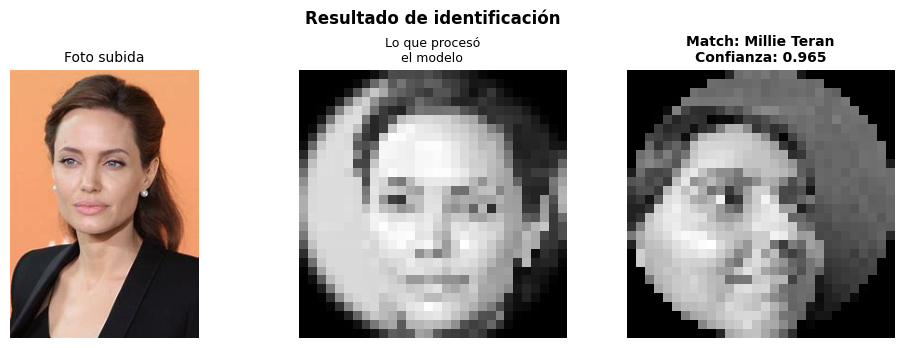


🎯 La red identificó a: MILLIE TERAN
   Confianza: 0.9654  ✅ Alta


In [119]:
## DEMO FINAL — subir una foto nueva y que la red diga quién es

from google.colab import files
import pickle

# ── 1. Cargar modelos PCA e ISOMAP guardados en Drive ────────
CARPETA_DATOS = "/content/buckets/b1/datos_30x30"

with open(f"{CARPETA_DATOS}/pca_model.pkl", "rb") as f:
    pca_cargado = pickle.load(f)

print("✅ Modelo PCA cargado")

# ── 2. Subir la foto ─────────────────────────────────────────
print("\n📸 Subí una foto de alguno de los 14 alumnos:")
uploaded = files.upload()
nombre_foto = list(uploaded.keys())[0]

# ── 3. Detectar y recortar la cara ───────────────────────────
# (las funciones leer_imagen y recortar_cara_por_borde vienen
#  del notebook 1 — si no están en memoria, copiá las celdas 5 y 6)

imagen = leer_imagen(f"/content/{nombre_foto}")
cara, cara_color, confianza = recortar_cara_por_borde(imagen)

# Respaldo con Haar si DeepFace falla
if cara is None:
    gris  = cv2.cvtColor(imagen, cv2.COLOR_BGR2GRAY)
    caras = clasificador_haar.detectMultiScale(
        gris, scaleFactor=1.1, minNeighbors=5, minSize=(40, 40)
    )
    if len(caras) > 0:
        x, y, w, h = sorted(caras, key=lambda c: c[2]*c[3], reverse=True)[0]
        cara = cv2.resize(gris[y:y+h, x:x+w], (TAMANO, TAMANO))
    else:
        print("❌ No se detectó cara. Probá con otra foto.")
        cara = None

if cara is not None:
    # ── 4. Proyectar con PCA ─────────────────────────────────
    vector        = cara.flatten().astype(float)
    proyeccion    = pca_cargado.transform([vector])   # shape (1, 80)

    # ── 5. Armar el DataFrame que espera predecir() ──────────
    data_nueva = {campos[i]: [proyeccion[0, i]] for i in range(n_componentes)}
    data_nueva["y"] = ["desconocido"]   # placeholder
    df_foto = pl.DataFrame(data_nueva)

    # ── 6. Predecir con la red neuronal ──────────────────────
    mp_frio = multiperceptron()
    mp_frio.cargar_modelo(carpeta)

    (y_hat, y_raw, _) = mp_frio.predecir(
        df_new=df_foto,
        campos=campos,
        clase="y"
    )

    alumno_predicho = y_hat[0].replace("_", " ").title()
    confianza_red   = y_raw[0]

  # ── 7. Mostrar resultado ──────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(10, 3.5))  # 3 columnas en vez de 2

# Columna 1: foto original en color
imagen_rgb = cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB)
axes[0].imshow(imagen_rgb)
axes[0].set_title("Foto subida", fontsize=10)
axes[0].axis("off")

# Columna 2: cara recortada (lo que vio el modelo)
axes[1].imshow(cara, cmap="gray")
axes[1].set_title("Lo que procesó\nel modelo", fontsize=9)
axes[1].axis("off")

# Columna 3: cara representativa del alumno predicho
alumno_key = y_hat[0]
imagenes_repr = np.load(f"{CARPETA_DATOS}/imagenes_repr.npz")
if alumno_key in imagenes_repr:
    axes[2].imshow(imagenes_repr[alumno_key], cmap="gray")
axes[2].set_title(f"Match: {alumno_predicho}\nConfianza: {confianza_red:.3f}",
                  fontsize=10, fontweight="bold")
axes[2].axis("off")

plt.suptitle("Resultado de identificación", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"\n🎯 La red identificó a: {alumno_predicho.upper()}")
print(f"   Confianza: {confianza_red:.4f}  {'✅ Alta' if confianza_red >= 0.85 else '⚠️ Baja — posible desconocido'}")